# Construccion de Dataset Multiespectral por Hoja (H x W x 10)

Este notebook crea un dataset donde cada muestra es una hoja recortada desde el .mat original conservando las 10 bandas espectrales.

Salida principal por hoja: tensor `.npy` con forma `(alto, ancho, 10)` y split `train/val/test` por hoja.

## 1. Librerias

In [1]:
import os
import re
import time
import shutil
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from scipy.io import loadmat

## 2. Configuracion

In [ ]:
# Longitudes de onda esperadas para las 10 bandas
LONGITUDES_DE_ONDA = [444, 475, 531, 560, 650, 668, 705, 717, 740, 848]
NUM_BANDAS_ESPERADAS = 10

# Split
SPLIT_SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15

# Extraccion
MIN_AREA = 20
OPENING_KERNEL = 3
MARGIN_PCT = 0.30

# Mantener fenomenos de intensidad entre bandas:
# - 'none': conserva valores originales
# - 'global_max': divide todo el cubo por su maximo global (preserva relaciones entre bandas)
NORMALIZATION_MODE = "global_max"

# Tamano de salida por cultivo
OUT_SIZE_BY_CROP = {
    "frijol": 128,
    "maiz": 240,
}

# Guardar preview RGB para inspeccion visual
SAVE_PREVIEW_RGB = False
PREVIEW_BANDS = (8, 4, 1)  # indices de bandas para visualizar

## 3. Utilidades de carga y parsing

In [3]:
def cargar_imagen_mat(filepath):
    mat_data = loadmat(filepath)
    if "R" not in mat_data:
        raise KeyError(f"No se encontro la clave 'R' en {filepath}")
    return mat_data["R"]


def cargar_mask_mat(filepath):
    mat_data = loadmat(filepath)
    if "class_map" not in mat_data:
        raise KeyError(f"No se encontro la clave 'class_map' en {filepath}")
    return mat_data["class_map"]


def parse_treatment(nombre_base):
    m = re.search(r"_T(\d+)", nombre_base)
    return int(m.group(1)) if m else 0


def encontrar_pares_ref_class(ruta_fecha):
    masks = [f for f in os.listdir(ruta_fecha) if f.startswith("CLASS") and f.endswith(".mat")]
    refs = [f for f in os.listdir(ruta_fecha) if f.startswith("REF") and f.endswith(".mat")]

    masks_dict = {}
    for m in masks:
        key = m.replace("CLASS__", "").replace("CLASS_", "")
        masks_dict[key] = m

    pares = []
    for r in sorted(refs):
        key = r.replace("REF__", "").replace("REF_", "")
        m = masks_dict.get(key)
        if m is not None:
            pares.append((r, m))
    return pares

## 4. Construccion de objetos (hojas) desde mascara

In [4]:
def construir_objetos_desde_mask(mask, min_area=20, opening_kernel=3):
    """
    Construye objetos por class_id usando connected components para IDs estables.
    Devuelve una lista ordenada con los pixeles de cada hoja.
    """
    class_ids = np.unique(mask)
    class_ids = class_ids[class_ids != 0]

    objetos = []

    for class_id in np.sort(class_ids):
        class_mask = (mask == class_id).astype(np.uint8) * 255

        if opening_kernel and opening_kernel > 1:
            kernel = np.ones((opening_kernel, opening_kernel), np.uint8)
            class_mask = cv2.morphologyEx(class_mask, cv2.MORPH_OPEN, kernel)

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(
            class_mask, connectivity=8, ltype=cv2.CV_32S
        )

        for i in range(1, num_labels):
            area = float(stats[i, cv2.CC_STAT_AREA])
            if area < float(min_area):
                continue

            pixels_y, pixels_x = np.where(labels == i)
            if len(pixels_x) == 0:
                continue

            objetos.append({
                "class_id": int(class_id),
                "pixels_x": pixels_x,
                "pixels_y": pixels_y,
                "cx": float(centroids[i][0]),
                "cy": float(centroids[i][1]),
                "area": area,
            })

    objetos = sorted(objetos, key=lambda o: (o["cy"], o["cx"], o["class_id"]))
    for idx, obj in enumerate(objetos, start=1):
        obj["object_local_id"] = idx

    return objetos

## 5. Recorte multiespectral por objeto (tensor H x W x 10)

In [5]:
def normalizar_cubo(cubo, mode="none", global_max=None):
    cubo = cubo.astype(np.float32, copy=False)

    if mode == "none":
        return cubo

    if mode == "global_max":
        maxv = float(global_max) if global_max is not None else float(np.max(cubo))
        if maxv <= 0:
            return cubo
        return cubo / maxv

    raise ValueError(f"Modo de normalizacion no soportado: {mode}")


def extraer_objeto_tensor_en_canvas(
    image_cube,
    pixels_x,
    pixels_y,
    out_size=128,
    margin_pct=0.30,
    normalization_mode="none",
):
    """
    Recorta un objeto desde image_cube (H, W, C), aplica mascara del objeto,
    redimensiona conservando proporcion y centra en canvas cuadrado.
    """
    h_img, w_img, c_img = image_cube.shape

    x_min, x_max = int(np.min(pixels_x)), int(np.max(pixels_x))
    y_min, y_max = int(np.min(pixels_y)), int(np.max(pixels_y))

    w_obj = x_max - x_min + 1
    h_obj = y_max - y_min + 1

    mx = int(round(w_obj * float(margin_pct)))
    my = int(round(h_obj * float(margin_pct)))

    x0 = max(0, x_min - mx)
    y0 = max(0, y_min - my)
    x1 = min(w_img, x_max + mx + 1)
    y1 = min(h_img, y_max + my + 1)

    crop_cube = image_cube[y0:y1, x0:x1, :].copy()
    if crop_cube.size == 0:
        return None

    local_h, local_w = crop_cube.shape[:2]
    local_mask = np.zeros((local_h, local_w), dtype=np.uint8)
    local_mask[pixels_y - y0, pixels_x - x0] = 255

    local_mask_bool = (local_mask > 0).astype(np.float32)
    crop_cube = crop_cube.astype(np.float32, copy=False) * local_mask_bool[:, :, None]

    global_max = float(np.max(image_cube)) if np.max(image_cube) > 0 else 1.0
    crop_cube = normalizar_cubo(crop_cube, mode=normalization_mode, global_max=global_max)

    h_crop, w_crop, _ = crop_cube.shape
    if h_crop == 0 or w_crop == 0:
        return None

    scale = min(out_size / w_crop, out_size / h_crop)
    new_w = max(1, int(round(w_crop * scale)))
    new_h = max(1, int(round(h_crop * scale)))

    resized = np.zeros((new_h, new_w, c_img), dtype=np.float32)
    for b in range(c_img):
        resized[:, :, b] = cv2.resize(crop_cube[:, :, b], (new_w, new_h), interpolation=cv2.INTER_AREA)

    canvas = np.zeros((out_size, out_size, c_img), dtype=np.float32)
    x_off = (out_size - new_w) // 2
    y_off = (out_size - new_h) // 2
    canvas[y_off:y_off + new_h, x_off:x_off + new_w, :] = resized

    return canvas


def guardar_preview_rgb(tensor_10ch, save_path, bands=(8, 4, 1)):
    b0, b1, b2 = bands
    rgb = np.stack([tensor_10ch[:, :, b0], tensor_10ch[:, :, b1], tensor_10ch[:, :, b2]], axis=2)

    maxv = float(np.max(rgb))
    if maxv > 0:
        rgb = (rgb / maxv) * 255.0
    rgb = rgb.astype(np.uint8)

    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(save_path), cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR))

## 6. Split por hoja (train/val/test)

In [6]:
def construir_split_hojas_estratificado(object_ids, tratamientos, train_ratio=0.7, val_ratio=0.15, seed=42):
    """
    Split por hoja (object_id) estratificado por tratamiento.
    Cada hoja se asigna independientemente a train/val/test.
    """
    if len(object_ids) == 0:
        return {}

    hojas_por_trat = {}
    for oid, tr in zip(object_ids, tratamientos):
        hojas_por_trat.setdefault(int(tr), []).append(oid)

    split_map = {}
    rng = np.random.default_rng(seed)

    for tr in sorted(hojas_por_trat.keys()):
        ids = sorted(hojas_por_trat[tr])
        n = len(ids)
        if n == 0:
            continue

        perm = rng.permutation(n)
        ids_perm = [ids[i] for i in perm]

        n_train = int(np.floor(n * float(train_ratio)))
        n_val = int(np.floor(n * float(val_ratio)))
        n_test = n - n_train - n_val

        if n >= 3:
            if n_train == 0:
                n_train = 1
            if n_val == 0:
                n_val = 1
            n_test = n - n_train - n_val
            if n_test == 0:
                if n_train >= n_val and n_train > 1:
                    n_train -= 1
                elif n_val > 1:
                    n_val -= 1
                n_test = n - n_train - n_val

        for i, oid in enumerate(ids_perm):
            if i < n_train:
                split_map[oid] = "train"
            elif i < n_train + n_val:
                split_map[oid] = "val"
            else:
                split_map[oid] = "test"

        print(f"Tratamiento T{tr}: total={n} -> train={n_train}, val={n_val}, test={n_test}")

    return split_map


## 7. Pipeline principal de construccion del dataset

In [ ]:
def construir_dataset_tensores_por_cultivo(
    cultivo,
    ruta_principal="data/mat",
    min_area=20,
    opening_kernel=3,
    margin_pct=0.30,
    split_seed=42,
    train_ratio=0.70,
    val_ratio=0.15,
    normalization_mode="global_max",
    save_preview_rgb=False,
):
    ruta_cultivo = os.path.join(ruta_principal, cultivo)
    if not os.path.isdir(ruta_cultivo):
        raise FileNotFoundError(f"No existe ruta de cultivo: {ruta_cultivo}")

    out_size = OUT_SIZE_BY_CROP.get(cultivo, 128)

    base_output_dir = f"extracted_tensors_{cultivo}_split_"
    output_manifest = f"datasets/object_split_{cultivo}_tensors.csv"

    if os.path.isdir(base_output_dir):
        shutil.rmtree(base_output_dir)

    print(f"\n=== Pasada 1: preparar records para {cultivo} ===")
    image_records = []

    for fecha in sorted(os.listdir(ruta_cultivo)):
        ruta_fecha = os.path.join(ruta_cultivo, fecha)
        if not os.path.isdir(ruta_fecha):
            continue

        pares = encontrar_pares_ref_class(ruta_fecha)
        for ref_file, class_file in pares:
            img_path = os.path.join(ruta_fecha, ref_file)
            mask_path = os.path.join(ruta_fecha, class_file)

            plant_id = os.path.splitext(ref_file)[0]
            tratamiento = parse_treatment(plant_id)

            try:
                mask = cargar_mask_mat(mask_path)
                objetos = construir_objetos_desde_mask(mask, min_area=min_area, opening_kernel=opening_kernel)

                object_ids = [f"{plant_id}__obj_{obj['object_local_id']:03d}" for obj in objetos]

                image_records.append({
                    "fecha": fecha,
                    "img_file": ref_file,
                    "class_file": class_file,
                    "img_path": img_path,
                    "mask_path": mask_path,
                    "plant_id": plant_id,
                    "tratamiento": tratamiento,
                    "object_ids": object_ids,
                })
            except Exception as e:
                print(f"Error preparando {ref_file}: {e}")

    if not image_records:
        raise ValueError(f"No se encontraron records validos para {cultivo}")

    # Recopilar todos los object_ids con su tratamiento
    all_obj_ids = []
    all_trats = []
    for rec in image_records:
        for obj_id in rec["object_ids"]:
            all_obj_ids.append(obj_id)
            all_trats.append(rec["tratamiento"])

    split_map_obj = construir_split_hojas_estratificado(
        all_obj_ids,
        all_trats,
        train_ratio=train_ratio,
        val_ratio=val_ratio,
        seed=split_seed,
    )

    if not split_map_obj:
        raise ValueError(f"No se pudo construir split por hoja para {cultivo}")

    print(f"\nSplit por hoja ({cultivo}): {pd.Series(split_map_obj).value_counts().to_dict()}")

    print(f"\n=== Pasada 2: extraccion de tensores para {cultivo} ===")
    rows = []

    for rec in image_records:
        try:
            image_cube = cargar_imagen_mat(rec["img_path"])
            mask = cargar_mask_mat(rec["mask_path"])

            if image_cube.ndim != 3:
                print(f"Saltando {rec['img_file']}: imagen no 3D")
                continue

            if image_cube.shape[2] != NUM_BANDAS_ESPERADAS:
                print(
                    f"Advertencia en {rec['img_file']}: se esperaban {NUM_BANDAS_ESPERADAS} bandas, "
                    f"pero se encontraron {image_cube.shape[2]}"
                )

            objetos = construir_objetos_desde_mask(mask, min_area=min_area, opening_kernel=opening_kernel)

            t0 = time.time()
            n_saved = 0

            for obj in objetos:
                object_id = f"{rec['plant_id']}__obj_{obj['object_local_id']:03d}"
                split = split_map_obj.get(object_id, "train")

                out_dir = os.path.join(base_output_dir, split, f"T{rec['tratamiento']}", rec["plant_id"])
                os.makedirs(out_dir, exist_ok=True)

                tensor = extraer_objeto_tensor_en_canvas(
                    image_cube=image_cube,
                    pixels_x=obj["pixels_x"],
                    pixels_y=obj["pixels_y"],
                    out_size=out_size,
                    margin_pct=margin_pct,
                    normalization_mode=normalization_mode,
                )

                if tensor is None:
                    continue

                tensor_path = os.path.join(out_dir, f"{object_id}.npy")
                np.save(tensor_path, tensor.astype(np.float32))

                preview_path = None
                if save_preview_rgb:
                    preview_path = os.path.join(out_dir, f"{object_id}_preview.png")
                    guardar_preview_rgb(tensor, preview_path, bands=PREVIEW_BANDS)

                rows.append({
                    "cultivo": cultivo,
                    "fecha": rec["fecha"],
                    "plant_id": rec["plant_id"],
                    "tratamiento": rec["tratamiento"],
                    "object_id": object_id,
                    "split": split,
                    "tensor_path": tensor_path,
                    "preview_path": preview_path,
                    "height": int(tensor.shape[0]),
                    "width": int(tensor.shape[1]),
                    "channels": int(tensor.shape[2]),
                    "dtype": str(tensor.dtype),
                    "nonzero_voxels": int(np.count_nonzero(tensor)),
                    "source_ref_file": rec["img_file"],
                    "source_class_file": rec["class_file"],
                })

                n_saved += 1

            dt = time.time() - t0
            print(f"Procesada {rec['img_file']}: objetos guardados={n_saved} | tiempo={dt:.2f}s")

        except Exception as e:
            print(f"Error procesando {rec['img_file']}: {e}")

    if not rows:
        raise ValueError(f"No se guardaron tensores para {cultivo}")

    os.makedirs("datasets", exist_ok=True)
    manifest_df = pd.DataFrame(rows)
    manifest_df.to_csv(output_manifest, index=False)

    print(f"\nDataset guardado en: {base_output_dir}")
    print(f"Manifest guardado en: {output_manifest}")
    print(f"Split por objetos ({cultivo}): {manifest_df['split'].value_counts().to_dict()}")

    return manifest_df, base_output_dir, output_manifest

## 8. Ejecutar construccion de dataset

In [8]:
manifest_frijol, out_frijol, csv_frijol = construir_dataset_tensores_por_cultivo(
    cultivo="frijol",
    ruta_principal="data/mat",
    min_area=MIN_AREA,
    opening_kernel=OPENING_KERNEL,
    margin_pct=MARGIN_PCT,
    split_seed=SPLIT_SEED,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    normalization_mode=NORMALIZATION_MODE,
    save_preview_rgb=SAVE_PREVIEW_RGB,
)

manifest_frijol.head()


=== Pasada 1: preparar records para frijol ===
Tratamiento T1: total=96 -> train=67, val=14, test=15
Tratamiento T2: total=96 -> train=67, val=14, test=15
Tratamiento T3: total=96 -> train=67, val=14, test=15
Tratamiento T4: total=95 -> train=66, val=14, test=15

Split por hoja (frijol): {'train': 267, 'test': 60, 'val': 56}

=== Pasada 2: extraccion de tensores para frijol ===
Procesada REF__0000_T2R1.mat: objetos guardados=32 | tiempo=0.55s
Procesada REF__0001_T1R1.mat: objetos guardados=32 | tiempo=0.54s
Procesada REF__0002_T2R2.mat: objetos guardados=32 | tiempo=0.54s
Procesada REF__0003_T1R2.mat: objetos guardados=32 | tiempo=0.70s
Procesada REF__0004_T2R3.mat: objetos guardados=32 | tiempo=0.58s
Procesada REF__0005_T1R3.mat: objetos guardados=32 | tiempo=0.55s
Procesada REF__0006_T3R1.mat: objetos guardados=32 | tiempo=0.68s
Procesada REF__0009_T3R2.mat: objetos guardados=32 | tiempo=0.52s
Procesada REF__0011_T3R3.mat: objetos guardados=32 | tiempo=0.53s
Procesada REF__0013_T4R1

,cultivo,fecha,plant_id,tratamiento,object_id,split,tensor_path,preview_path,height,width,channels,dtype,nonzero_voxels,source_ref_file,source_class_file
0,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_001,val,extracted_tensors_frijol_split_v1\val\T2\REF__...,None,128,128,10,float32,36200,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat
1,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_002,test,extracted_tensors_frijol_split_v1\test\T2\REF_...,None,128,128,10,float32,38680,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat
2,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_003,train,extracted_tensors_frijol_split_v1\train\T2\REF...,None,128,128,10,float32,32180,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat
3,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_004,train,extracted_tensors_frijol_split_v1\train\T2\REF...,None,128,128,10,float32,34870,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat
4,frijol,Nov_3_2021,REF__0000_T2R1,2,REF__0000_T2R1__obj_005,train,extracted_tensors_frijol_split_v1\train\T2\REF...,None,128,128,10,float32,34420,REF__0000_T2R1.mat,CLASS__0000_T2R1.mat


In [9]:
manifest_maiz, out_maiz, csv_maiz = construir_dataset_tensores_por_cultivo(
    cultivo="maiz",
    ruta_principal="data/mat",
    min_area=MIN_AREA,
    opening_kernel=OPENING_KERNEL,
    margin_pct=MARGIN_PCT,
    split_seed=SPLIT_SEED,
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    normalization_mode=NORMALIZATION_MODE,
    save_preview_rgb=SAVE_PREVIEW_RGB,
)

manifest_maiz.head()


=== Pasada 1: preparar records para maiz ===
Tratamiento T1: total=187 -> train=130, val=28, test=29
Tratamiento T2: total=167 -> train=116, val=25, test=26
Tratamiento T3: total=112 -> train=78, val=16, test=18
Tratamiento T4: total=111 -> train=77, val=16, test=18

Split por hoja (maiz): {'train': 401, 'test': 91, 'val': 85}

=== Pasada 2: extraccion de tensores para maiz ===
Procesada REF__0002_T1R1G10G4.mat: objetos guardados=8 | tiempo=0.30s
Procesada REF__0004_T3R1G6G3.mat: objetos guardados=8 | tiempo=0.23s
Procesada REF__0006_T1R1G7G8.mat: objetos guardados=8 | tiempo=0.23s
Procesada REF__0006_T3R1G10G9.mat: objetos guardados=8 | tiempo=0.22s
Procesada REF__0008_T1R1G6G1.mat: objetos guardados=9 | tiempo=0.23s
Procesada REF__0008_T3R1G2G8.mat: objetos guardados=8 | tiempo=0.21s
Procesada REF__0010_T3R1G5G7.mat: objetos guardados=8 | tiempo=0.19s
Procesada REF__0012_T1R1G3G2.mat: objetos guardados=8 | tiempo=0.25s
Procesada REF__0012_T3R1G1G4.mat: objetos guardados=8 | tiempo=0

,cultivo,fecha,plant_id,tratamiento,object_id,split,tensor_path,preview_path,height,width,channels,dtype,nonzero_voxels,source_ref_file,source_class_file
0,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_001,train,extracted_tensors_maiz_split_v1\train\T1\REF__...,None,240,240,10,float32,33070,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat
1,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_002,test,extracted_tensors_maiz_split_v1\test\T1\REF__0...,None,240,240,10,float32,29370,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat
2,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_003,val,extracted_tensors_maiz_split_v1\val\T1\REF__00...,None,240,240,10,float32,18240,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat
3,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_004,test,extracted_tensors_maiz_split_v1\test\T1\REF__0...,None,240,240,10,float32,29900,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat
4,maiz,Jun_23_2022,REF__0002_T1R1G10G4,1,REF__0002_T1R1G10G4__obj_005,val,extracted_tensors_maiz_split_v1\val\T1\REF__00...,None,240,240,10,float32,28100,REF__0002_T1R1G10G4.mat,CLASS__0002_T1R1G10G4.mat


## 9. Validación del dataset de tensores

In [ ]:
def validar_dataset_tensores(cultivo, expected_channels=10):
    base_dir = f"extracted_tensors_{cultivo}_split"
    manifest_path = f"datasets/object_split_{cultivo}_tensors.csv"

    print(f"\n=== QA tensores: {cultivo.upper()} ===")

    if not os.path.isdir(base_dir):
        print(f"No existe directorio: {base_dir}")
        return None
    if not os.path.isfile(manifest_path):
        print(f"No existe manifest: {manifest_path}")
        return None

    manifest = pd.read_csv(manifest_path)
    required_cols = {"object_id", "split", "tensor_path"}
    if not required_cols.issubset(set(manifest.columns)):
        print(f"Manifest invalido. Faltan: {sorted(required_cols - set(manifest.columns))}")
        return None

    rows = []
    for split in ["train", "val", "test"]:
        split_path = os.path.join(base_dir, split)
        if not os.path.isdir(split_path):
            continue

        for root, _, files in os.walk(split_path):
            npy_files = [f for f in files if f.lower().endswith(".npy")]
            for f in npy_files:
                p = os.path.join(root, f)
                obj_id = os.path.splitext(f)[0]
                try:
                    t = np.load(p, mmap_mode="r")
                    shape = tuple(t.shape)
                    dtype = str(t.dtype)
                except Exception as e:
                    shape = None
                    dtype = f"error: {e}"

                rows.append({
                    "object_id": obj_id,
                    "split_folder": split,
                    "tensor_path_found": p,
                    "shape": shape,
                    "dtype_found": dtype,
                })

    if not rows:
        print("No se encontraron tensores .npy")
        return None

    df = pd.DataFrame(rows)

    ids_train = set(df.loc[df["split_folder"] == "train", "object_id"].unique())
    ids_val = set(df.loc[df["split_folder"] == "val", "object_id"].unique())
    ids_test = set(df.loc[df["split_folder"] == "test", "object_id"].unique())

    overlap = (ids_train & ids_val) | (ids_train & ids_test) | (ids_val & ids_test)
    print(f"Objetos unicos: {df['object_id'].nunique()}")
    print(f"Tensores totales: {len(df)}")
    print(f"Leakage de object_id entre splits: {len(overlap)}")

    manifest_map = manifest.set_index("object_id")["split"].to_dict()
    df["split_manifest"] = df["object_id"].map(manifest_map)

    missing_manifest = int(df["split_manifest"].isna().sum())
    mismatch_split = int(((~df["split_manifest"].isna()) & (df["split_manifest"] != df["split_folder"])) .sum())

    print(f"object_id fuera de manifest: {missing_manifest}")
    print(f"split distinto a manifest: {mismatch_split}")

    def canales_ok(shape):
        return isinstance(shape, tuple) and len(shape) == 3 and shape[2] == expected_channels

    bad_shape = int((~df["shape"].apply(canales_ok)).sum())
    print(f"Tensores con shape/canales no validos: {bad_shape}")

    print("Conteo por split:")
    print(df["split_folder"].value_counts().to_string())

    ok = (len(overlap) == 0) and (missing_manifest == 0) and (mismatch_split == 0) and (bad_shape == 0)
    print("Resultado QA:", "APROBADO" if ok else "REVISAR")

    return {"ok": ok, "df": df, "manifest": manifest}


qa_frijol = validar_dataset_tensores("frijol", expected_channels=NUM_BANDAS_ESPERADAS)
qa_maiz = validar_dataset_tensores("maiz", expected_channels=NUM_BANDAS_ESPERADAS)


=== QA tensores: FRIJOL ===
Objetos unicos: 383
Tensores totales: 383
Leakage de object_id entre splits: 0
object_id fuera de manifest: 0
split distinto a manifest: 0
Tensores con shape/canales no validos: 0
Conteo por split:
split_folder
train    267
test      60
val       56
Resultado QA: APROBADO

=== QA tensores: MAIZ ===
Objetos unicos: 577
Tensores totales: 577
Leakage de object_id entre splits: 0
object_id fuera de manifest: 0
split distinto a manifest: 0
Tensores con shape/canales no validos: 0
Conteo por split:
split_folder
train    401
test      91
val       85
Resultado QA: APROBADO


## 10. Inspeccion rapida de una muestra

object_id: REF__0000_T2R1__obj_001
split: val
shape: (128, 128, 10) dtype: float32


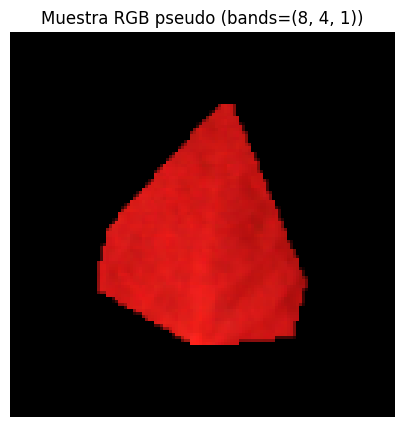

In [11]:
def mostrar_muestra_tensor(manifest_df, idx=0, bands=(8, 4, 1)):
    row = manifest_df.iloc[idx]
    tensor = np.load(row["tensor_path"])

    print("object_id:", row["object_id"])
    print("split:", row["split"])
    print("shape:", tensor.shape, "dtype:", tensor.dtype)

    rgb = np.stack([tensor[:, :, bands[0]], tensor[:, :, bands[1]], tensor[:, :, bands[2]]], axis=2)
    maxv = float(np.max(rgb))
    if maxv > 0:
        rgb = rgb / maxv

    import matplotlib.pyplot as plt
    plt.figure(figsize=(5, 5))
    plt.imshow(rgb)
    plt.title(f"Muestra RGB pseudo (bands={bands})")
    plt.axis("off")
    plt.show()


mostrar_muestra_tensor(manifest_frijol, idx=0, bands=PREVIEW_BANDS)

object_id: REF__0002_T1R1G10G4__obj_001
split: train
shape: (240, 240, 10) dtype: float32


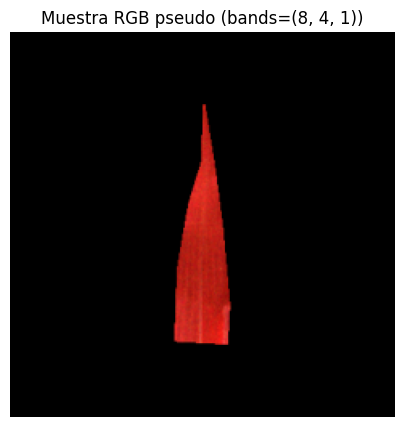

In [12]:
mostrar_muestra_tensor(manifest_maiz, idx=0, bands=PREVIEW_BANDS)